# Семинар 2. RAG, векторная база и память агента

На прошлой неделе агент ходил за фактами в живую Википедию и отвечал на 58 процентов свежих вопросов. Сегодня кладём знания рядом: режем корпус на куски, считаем эмбеддинги, ищем сначала на numpy, потом в Milvus, собираем RAG-ответ с источниками, разбираем провалы и даём агенту память. В конце превращаем поиск в инструмент агента. Дополнение для желающих: тот же конвейер на PDF.

Тезис курса прежний: **хороший агент на дешёвой модели обходится дешевле сильной модели в одиночку при том же качестве.** Сегодняшний вопрос к нему: сколько стоит верный ответ, когда знания лежат в индексе, и сколько в этой цене занимает контекст.

Восемь спринтов, десять дырок. Дырка это функция, у которой вместо тела стоит `...`, ни одна не длиннее десяти строк. Пояснения к дыркам, хронометраж и домашка в `README.md`.

## Что нужно

**Ключ** OpenRouter: локально файл `.env` рядом с ноутбуком, в Kaggle секрет `OPENROUTER_API_KEY` (Add-ons, Secrets, галочка подключения, перезапуск сессии). **Данные**: папка `data` рядом с ноутбуком, в Kaggle датасет `seminar02-data` и включённый Internet.

**Milvus** в Docker: в папке семинара лежит `docker-compose.yml`, команда `docker compose up -d` поднимает базу на `localhost:19530`. Первый запуск скачивает образ, около гигабайта, поэтому сделайте это до семинара. Если Docker поставить нельзя (Kaggle, Colab), в README есть раздел «Нет Docker».

В данных лежит готовый файл эмбеддингов корпуса `embeddings_512.npz`. С ним второй спринт занимает секунды. Без него те же векторы посчитаются через API за цент и минут двадцать: так было у нас при подготовке, и на общей сети аудитории будет не быстрее.

## HW | Шаг 1. Корпус и вопросы (Создание корпуса)

In [1]:
import re
import json
from pathlib import Path

from curl_cffi import requests
from bs4 import BeautifulSoup


YEARS = [2025,2026]          
MONTHS = list(range(1,13))   
OUTPUT = Path("data/corpus.jsonl")

MONTH_NAMES = {
    1: "january",
    2: "february",
    3: "march",
    4: "april",
    5: "may",
    6: "june",
    7: "july",
    8: "august",
    9: "september",
    10: "october",
    11: "november",
    12: "december",
}



def collect_month(session, year, month):
    month_en = MONTH_NAMES[month]
    url = (
        f"https://genius.com/Genius-russia-{year}-"
        f"{month_en}-album-release-calendar-annotated"
    )

    response = session.get(url, impersonate="chrome", timeout=30)
    response.raise_for_status()

    soup = BeautifulSoup(response.content, "html.parser")
    blocks = soup.select('[data-lyrics-container="true"]')

    if not blocks:
        raise ValueError(f"Календарь не найден: {url}")

    title = soup.find("h1")
    if title is None:
        raise ValueError(f"Заголовок страницы не найден: {url}")

    page = title.get_text(" ", strip=True)
    print(page)

    parts = []
    for block in blocks:
        for element in block.select('[data-exclude-from-selection="true"]'):
            element.decompose()

        for br in block.find_all("br"):
            br.replace_with("\n")

        parts.append(block.get_text())

    raw_text = "\n".join(parts)

  
    raw_text = raw_text.replace("\\", "")

    raw_text = re.sub(
        r'(\d+/\d+)(?=(0[1-9]|[12][0-9]|3[01])/(0[1-9]|1[0-2]))',
        r'\1\n',
        raw_text
    )

    raw_text = re.sub(
        r'(?m)^((0[1-9]|[12][0-9]|3[01])/(0[1-9]|1[0-2]))(?=[^\d/]|$)',
        r'\n==\1==',
        raw_text
    )

    raw_text = re.sub(r'\n(?===)', '@@KEEP_NL@@', raw_text)
    raw_text = raw_text.replace("\n", " ")
    raw_text = raw_text.replace("@@KEEP_NL@@", "\n")
    raw_text = re.sub(r'\s*(==\d{2}/\d{2}==)\s*', r'\n\1 ', raw_text)
    text = re.sub(r'[ \t]+', ' ', raw_text).strip()
    text = re.sub(r'\n+', '\n', text)

    if not text:
        raise ValueError(f"Пустой текст календаря: {url}")

    return {
        "page": page,
        "url": url,
        "text": text,
    }


def main():
    months = list(dict.fromkeys(MONTHS))
    if not months or any(month not in MONTH_NAMES for month in months):
        raise ValueError("MONTHS должен содержать номера месяцев от 1 до 12.")

    dataset = []

    with requests.Session() as session:
        for year in YEARS:
            for month in months:
                try:
                    record = collect_month(session, year, month)
                    dataset.append(record)
                    print(f"{year}-{month:02d}: {len(record['text'])} символов")
                except Exception as e:
                    print(f"Ошибка за {year}-{month:02d}: {e}")

    OUTPUT.parent.mkdir(parents=True, exist_ok=True)

    with OUTPUT.open("w", encoding="utf-8") as file:
        for record in dataset:
            file.write(json.dumps(record, ensure_ascii=False) + "\n")

    print(f"Готово: {len(dataset)} страниц → {OUTPUT}")

main()

Календарь релизов января 2025 (January Album Release Calendar)
2025-01: 2211 символов
Календарь релизов февраля 2025 (February Album Release Calendar)
2025-02: 2213 символов
Календарь релизов марта 2025 (March Album Release Calendar)
2025-03: 2620 символов
Календарь релизов апреля 2025 (April Album Release Calendar)
2025-04: 3056 символов
Календарь релизов мая 2025 (May Album Release Calendar)
2025-05: 1972 символов
Календарь релизов июня 2025 (June Album Release Calendar)
2025-06: 1304 символов
Календарь релизов июля 2025 (July Album Release Calendar)
2025-07: 3268 символов
Календарь релизов августа 2025 (August Album Release Calendar)
2025-08: 3179 символов
Календарь релизов сентября 2025 (September Album Release Calendar)
2025-09: 1867 символов
Календарь релизов октября 2025 (October Album Release Calendar)
2025-10: 4108 символов
Календарь релизов ноября 2025 (November Album Release Calendar)
2025-11: 3219 символов
Календарь релизов декабря 2025 (December Album Release Calendar)
202

In [2]:
import os, re, sys, json, time, hashlib, threading
from pathlib import Path
from dataclasses import dataclass, field
from concurrent.futures import ThreadPoolExecutor
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from pymilvus import MilvusClient

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass
try:
    from kaggle_secrets import UserSecretsClient
    os.environ.setdefault("OPENROUTER_API_KEY", UserSecretsClient().get_secret("OPENROUTER_API_KEY"))
except Exception:
    pass
assert os.getenv("OPENROUTER_API_KEY"), "нет ключа: положите его в .env рядом с ноутбуком или в Kaggle Secrets"

CHAT_URL = "https://openrouter.ai/api/v1/chat/completions"
EMBED_URL = "https://openrouter.ai/api/v1/embeddings"
HEADERS = {"Authorization": f"Bearer {os.environ['OPENROUTER_API_KEY']}", "X-Title": "agents-course-seminar02"}
MODELS = {"cheap": "openai/gpt-4o-mini", "mid": "anthropic/claude-haiku-4.5", "strong": "anthropic/claude-sonnet-4.6"}
EMBED_MODEL, DIM = "openai/text-embedding-3-small", 512
COLORS = {"violet": "#5436A3", "amber": "#F09000", "teal": "#00838F", "red": "#C43C3C", "grey": "#787882"}
DATA = next((p for p in [Path("data"), Path("/kaggle/input/seminar02-data"), Path("/kaggle/input/seminar02-data/data")]
             if (p / "corpus.jsonl").exists()), Path("data"))
Path("img").mkdir(exist_ok=True)


@dataclass
class Ledger:
    calls: list = field(default_factory=list)
    local: threading.local = field(default_factory=threading.local)

    def add(self, tag, model, usage, seconds=0.0):
        cost = usage.get("cost") or 0.0
        self.calls.append({"tag": tag, "model": model.split("/")[-1], "prompt": usage.get("prompt_tokens", 0),
                           "completion": usage.get("completion_tokens", 0), "cost": cost, "seconds": round(seconds, 2)})
        self.local.spent = self.mine + cost
        return cost

    @property
    def total(self):
        return sum(c["cost"] for c in self.calls)

    @property
    def mine(self):
        return getattr(self.local, "spent", 0.0)

    def table(self):
        frame = pd.DataFrame(self.calls, columns=["tag", "model", "prompt", "completion", "cost", "seconds"])
        return frame.groupby(["tag", "model"]).agg(calls=("cost", "size"), prompt=("prompt", "sum"),
                                                                      completion=("completion", "sum"), cost=("cost", "sum")).round(5)


ledger = Ledger()


def post_with_retry(url, body, attempts=5):
    problem = "нет ответа"
    for attempt in range(attempts):
        try:
            r = requests.post(url, json=body, headers=HEADERS, timeout=120)
            if r.status_code == 200:
                return r.json()
            problem = f"HTTP {r.status_code}: {r.text[:200]}"
            if r.status_code not in (429, 500, 502, 503, 504):
                break
        except requests.RequestException as e:
            problem = type(e).__name__
        time.sleep(2.0 * (attempt + 1))
    raise RuntimeError(problem)


def chat(messages, model, tools=None, tag="chat"):
    body = {"model": model, "messages": messages, "temperature": 0, "usage": {"include": True}}
    if tools:
        body["tools"] = tools
    started = time.perf_counter()
    data = post_with_retry(CHAT_URL, body)
    ledger.add(tag, model, data.get("usage") or {}, time.perf_counter() - started)
    return data["choices"][0]["message"]


def load_jsonl(name):
    return [json.loads(line) for line in (DATA / name).read_text(encoding="utf-8").splitlines() if line.strip()]

## Спринт 1. Корпус и нарезка

Корпус это 28 обзорных страниц Википедии про 2026 год, 830 тысяч символов. Вопросы те же, что в первой домашке: 124 штуки, на которых Sonnet без инструментов не отвечает. У каждого вопроса есть поле `evidence`, исходная строка с ответом, поэтому мы точно знаем, какой кусок верный, и сможем считать качество поиска без ручной разметки.

Страница устроена как список датированных событий: одна строка, одно событие. Отсюда два способа резать. Наивный: по 400 символов, не глядя на границы. По структуре: одна строка это один кусок, а заголовок раздела (месяц) едет с куском как метаданные.

Дырка: нарезка по строкам. Чекпоинт: число кусков в обеих нарезках и пример факта, который наивная нарезка разорвала пополам.

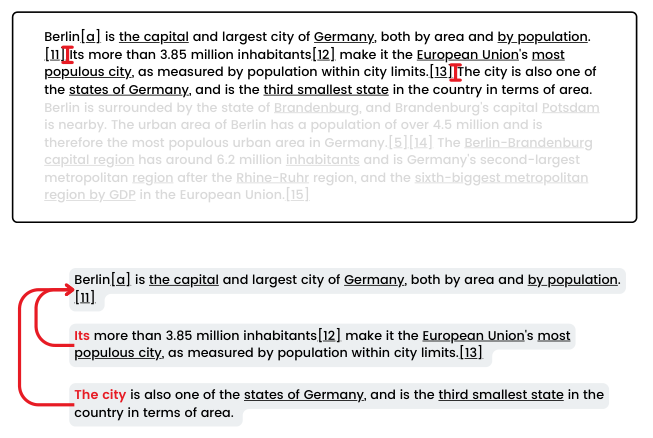

*Günther et al., 2024. Кусок без контекста: во втором и третьем предложении слова «Берлин» уже нет. Поэтому к тексту куска мы приписываем название страницы*

In [11]:
corpus, tasks = load_jsonl("corpus.jsonl"), load_jsonl("fresh.jsonl")
len(corpus), sum(len(p["text"]) for p in corpus), len(tasks), tasks[0]

(24,
 54437,
 90,
 {'id': 'fresh-0',
  'source': 'fresh',
  'question': 'На какую дату в календаре Genius Russia за 2026 год указан релиз «YOUNG and BROKEN» исполнителя 3g0th2002?',
  'answer': '01/05',
  'evidence': '01/05\n3g0th2002 — YOUNG and BROKEN — 8/8',
  'page': 'Календарь релизов мая 2026 (May Album Release Calendar)',
  'url': 'https://genius.com/Genius-russia-2026-may-album-release-calendar-annotated'})

In [16]:
def chunk_lines(page):
    chunks = []
    text = page["text"]
    parts = re.split(r"(==\d{2}/\d{2}==)", text)
    section = ""

    for part in parts:
        part = part.strip()
        if not part:
            continue
        if part.startswith("=="):
            section = part.strip("= ")
            continue

        ends = [m.end() for m in re.finditer(r"—\s*\d+/\d+|\?/\?", part)]
        if not ends:
            chunks.append({
                "page": page["page"], "section": section,
                "url": page["url"], "text": f"{section} {part}",
            })
            continue

        start = 0
        for end in ends:
            rel = part[start:end].strip()
            start = end
            if rel:
                chunks.append({
                    "page": page["page"], "section": section,
                    "url": page["url"], "text": f"{section} {rel}",
                })

    return chunks

In [20]:
def chunk_chars(page, size=60):
    text = " ".join(page["text"].split())
    return [{"page": page["page"], "section": "", "url": page["url"], "text": text[i:i + size]} for i in range(0, len(text), size)]

line_chunks = [c for p in corpus for c in chunk_lines(p)]
char_chunks = [c for p in corpus for c in chunk_chars(p)]
len(line_chunks), len(char_chunks)

(1511, 916)

In [21]:
def torn(task):
    words = re.findall(r"\w+", task["evidence"].lower())
    head, tail = " ".join(words[:6]), " ".join(words[-6:])
    parts = [c["text"] for c in char_chunks if c["page"] == task["page"]
             and (head in " ".join(re.findall(r"\w+", c["text"].lower())) or tail in " ".join(re.findall(r"\w+", c["text"].lower())))]
    return parts if len(parts) >=1 else None

example = next(t for t in tasks if torn(t))
print("вопрос:", example["question"], "| ответ:", example["answer"])
for n, part in enumerate(torn(example), 1):
    print(f"кусок {n}: ...{part[-160:]}" if n == 1 else f"кусок {n}: {part[:160]}...")

вопрос: На какую дату в календаре Genius Russia за 2026 год указан релиз «YOUNG and BROKEN» исполнителя 3g0th2002? | ответ: 01/05
кусок 1: ...==01/05== 3g0th2002 — YOUNG and BROKEN — 8/8 3umph — поколен


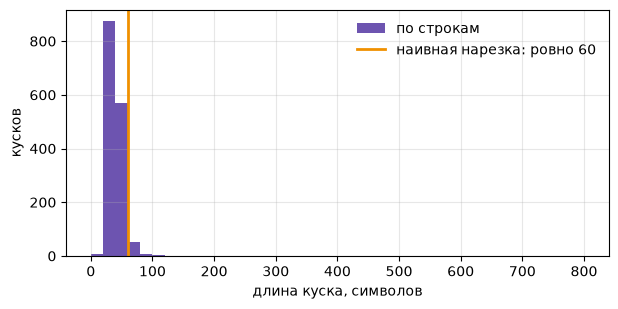

In [22]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist([len(c["text"]) for c in line_chunks], bins=40, range=(0, 800), color=COLORS["violet"], alpha=0.85, label="по строкам")
ax.axvline(60, color=COLORS["amber"], lw=2, label="наивная нарезка: ровно 60")
ax.set_xlabel("длина куска, символов"); ax.set_ylabel("кусков"); ax.legend(frameon=False); ax.grid(alpha=0.3);

## Спринт 2. Эмбеддинги и кэш

Эмбеддинг текста не меняется, пока не меняются текст и модель, поэтому считать его дважды незачем. Кэш устроен просто: ключ это хэш текста, значение это вектор. Сначала в кэш загружается готовый файл из данных, потом всё, чего там нет, досчитывается через API пачками по 64 текста.

Вектор берём укороченный, 512 измерений вместо 1536: это «матрёшка» из пятой лекции, параметр `dimensions` в запросе. Ответ API втрое легче, память втрое меньше, качество почти то же. Пачка в 256 текстов на полной размерности это восемь мегабайт JSON, и на медленной сети такой запрос просто не доходит.

Дырка: `embed_cached`. Чекпоинт: матрицы векторов для обеих нарезок и вопросов и строка в леджере с ценой.

In [23]:
EMB = {}

def load_cache():
    for path in [DATA / "embeddings_512.npz", Path("emb_cache.npz")]:
        if path.exists():
            z = np.load(path)
            EMB.update({str(k): v.astype(np.float32) for k, v in zip(z["keys"], z["vectors"])})
    return len(EMB)

def save_cache():
    np.savez_compressed("emb_cache.npz", keys=np.array(list(EMB)), vectors=np.stack(list(EMB.values())).astype(np.float16))

def embed_batch(texts):
    started = time.perf_counter()
    data = post_with_retry(EMBED_URL, {"model": EMBED_MODEL, "input": texts, "dimensions": DIM})
    ledger.add("embed", EMBED_MODEL, data.get("usage") or {}, time.perf_counter() - started)
    return [row["embedding"] for row in data["data"]]

def key_of(text):
    return hashlib.sha1(text.encode("utf-8")).hexdigest()

load_cache()

0

In [24]:
def embed_cached(texts):
    missing = list(dict.fromkeys(t for t in texts if key_of(t) not in EMB)) #set нельзя т.к. нет порядка
    for i in range(0, len(missing), 64):
        batch = missing[i:i+64]
        for text, vector in zip(batch, embed_batch(batch)):
            EMB[key_of(text)] = np.asarray(vector, dtype=np.float32)

    vectors = np.stack([EMB[key_of(t)] for t in texts])
    return vectors / np.linalg.norm(vectors, axis=1, keepdims=True)

In [25]:
def emb_text(chunk):
    return f"{chunk['page']}: {chunk['text']}"

line_vecs = embed_cached([emb_text(c) for c in line_chunks])
char_vecs = embed_cached([c["text"] for c in char_chunks])
q_vecs = embed_cached([t["question"] for t in tasks])
save_cache()
line_vecs.shape, char_vecs.shape, q_vecs.shape

((1511, 512), (916, 512), (90, 512))

In [26]:
probe = embed_cached(["Apple is a big techological company in USA", "Green apple is a tasty food from the my garden", "What was the weather in Tokyo yesterday?"])
save_cache()
(probe @ probe.T).round(2), ledger.table()

(array([[1.  , 0.27, 0.01],
        [0.27, 1.  , 0.02],
        [0.01, 0.02, 1.  ]], dtype=float32),
                               calls  prompt  completion   cost
 tag   model                                                   
 embed text-embedding-3-small     42  100034           0  0.002)

## Спринт 3. Поиск на numpy и recall@k

Векторы нормализованы, значит косинусная близость это скалярное произведение, а близость вопроса ко всему корпусу это одно умножение матрицы на вектор. Для шести тысяч кусков этого хватает с запасом.

Качество поиска меряем отдельно от качества ответа. `recall@k` это доля вопросов, у которых верный кусок попал в первые k. Верным считаем кусок с той же страницы, в котором есть ответ и не меньше половины слов исходной строки: так наивная нарезка честно получает штраф за разорванные факты.

Дырка: `search_numpy`. Чекпоинт: кривая recall@k для двух нарезок.

In [27]:
def search_numpy(query_vec, vectors, k=5):
    sims = vectors @ query_vec
    top = np.argsort(-sims)[:k]
    return[(int(i), float(sims[i])) for i in top]


In [28]:
NUMBERS = {word: str(n) for n, word in enumerate("zero one two three four five six seven eight nine ten eleven twelve".split())}

def norm(text):
    words = re.sub(r"\b(a|an|the)\b|[^\w\s]", " ", str(text).lower()).split()
    return " ".join(NUMBERS.get(w, w) for w in words)

def is_gold(chunk, task):
    if chunk["page"] != task["page"]:
        return False
    text, words = norm(chunk["text"]), norm(task["evidence"]).split()
    return norm(task["answer"]) in text and sum(w in text for w in words) >= 0.5 * len(words)

def recall_curve(chunks, vectors, ks=(1, 3, 5, 10, 20)):
    ranked = [[i for i, _ in search_numpy(q, vectors, max(ks))] for q in q_vecs]
    return {k: float(np.mean([any(is_gold(chunks[i], t) for i in r[:k]) for r, t in zip(ranked, tasks)])) for k in ks}

for i, score in search_numpy(q_vecs[0], line_vecs, 3):
    print(round(score, 3), "|", line_chunks[i]["page"], "|", line_chunks[i]["text"])
tasks[0]["question"], tasks[0]["answer"]

0.676 | Календарь релизов мая 2026 (May Album Release Calendar) | 01/05 3g0th2002 — YOUNG and BROKEN — 8/8
0.603 | Календарь релизов января 2026 (January Album Release Calendar) | 30/01 молодой рубль — быстрые мысли — 6/6
0.59 | Календарь релизов апреля 2026 (April Album Release Calendar) | 10/04 J. ROUH — РУССКАЯ БРАЗИЛИЯ — 11/11


('На какую дату в календаре Genius Russia за 2026 год указан релиз «YOUNG and BROKEN» исполнителя 3g0th2002?',
 '01/05')

,по строкам,по 400 символов
1,0.97,0.21
3,1.00,0.21
5,1.00,0.23
10,1.00,0.28
20,1.00,0.30


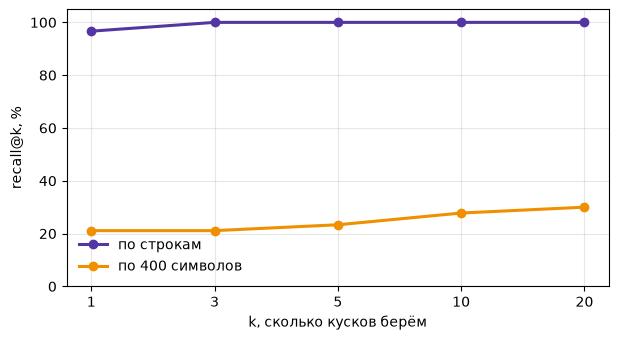

In [29]:
curves = {"по строкам": recall_curve(line_chunks, line_vecs), "по 400 символов": recall_curve(char_chunks, char_vecs)}
fig, ax = plt.subplots(figsize=(7, 3.6))
for (name, curve), color in zip(curves.items(), [COLORS["violet"], COLORS["amber"]]):
    ax.plot([str(k) for k in curve], [v * 100 for v in curve.values()], marker="o", lw=2.2, color=color, label=name)
ax.set_xlabel("k, сколько кусков берём"); ax.set_ylabel("recall@k, %"); ax.set_ylim(0, 105); ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.savefig("img/recall.png", dpi=150, bbox_inches="tight")
pd.DataFrame(curves).round(2)

При k=3  осмысленная нарезка выигрывает

## Спринт 4. Milvus

Перебор на numpy честный и быстрый, но это только поиск. База добавляет то, что нужно продукту: хранение на диске, метаданные рядом с вектором, фильтры, добавление и удаление без пересборки, индекс для миллионов векторов и доступ по сети для нескольких сервисов сразу.

Milvus поднимаем так же, как его поднимают в жизни: контейнером. В папке семинара лежит `docker-compose.yml`, в нём один сервис, сам Milvus в режиме standalone со встроенным etcd и локальным хранилищем.

```
docker compose up -d        поднять, база слушает localhost:19530
docker compose ps           статус должен стать healthy
docker compose logs -f      посмотреть, что происходит внутри
docker compose down         остановить, данные останутся в томе
docker compose down -v      остановить и стереть данные
```

В боевой установке etcd и объектное хранилище (MinIO или S3) живут отдельными сервисами, а сам Milvus раскладывается на несколько узлов. Код клиента от этого не меняется: меняется только адрес в `MILVUS_URI`.

Рядом с вектором храним всё, что понадобится показать человеку и подложить модели: текст куска, страницу, раздел, ссылку. Поля, которых нет в схеме, Milvus складывает как динамические, и по ним можно фильтровать. После вставки зовём `flush`: он запечатывает сегмент, по нему строится индекс, а `row_count` в статистике становится точным.

Две дырки: загрузка кусков в коллекцию и поиск с фильтром. Чекпоинт: выдача Milvus почти полностью совпадает с перебором, фильтр по странице работает, и два замера скорости: на нашем корпусе и на корпусе, раздутом до двухсот тысяч векторов.

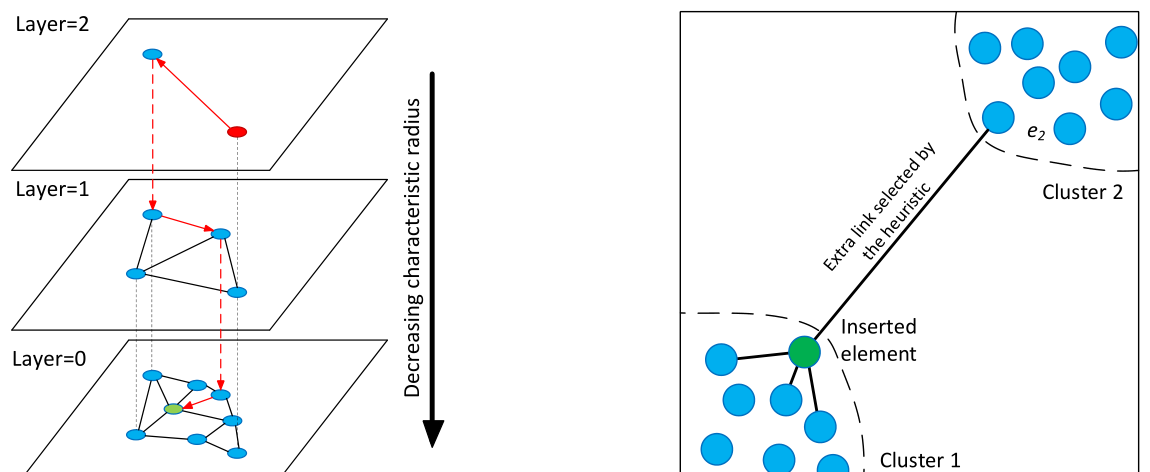

*Malkov, Yashunin, 2016. HNSW: слои графа как автострады и улицы. Milvus строит такой индекс сам, поэтому поиск приближённый: быстрый, но совпадает с перебором не на все сто процентов*

In [31]:
MILVUS_URI = os.getenv("MILVUS_URI", "http://localhost:19530")
client = MilvusClient(uri=MILVUS_URI, token=os.getenv("MILVUS_TOKEN", ""))
if os.getenv("MILVUS_DB"):
    if os.environ["MILVUS_DB"] not in client.list_databases():
        client.create_database(os.environ["MILVUS_DB"])
    client.use_database(os.environ["MILVUS_DB"])
client.get_server_version(), client.list_collections()

('2.6.24', [])

In [32]:
def index_to_milvus(name, chunks, vectors):
    if client.has_collection(name):
        client.drop_collection
    client.create_collection(name, dimension=vectors.shape[1], metric_type="COSINE")
    rows = [{"id": i, "vector": v.tolist(), **c} for i, (c, v) in enumerate(zip(chunks, vectors))]
    for i in range(0, len(rows), 1000):
        client.insert(name, rows[i:i+1000])

    client.flush(name)
    return client.get_collection_stats(name)

In [33]:
def search_milvus(name, query, k=5, flt=""):
    vector = embed_cached([query])[0].tolist()
    hits = client.search(name, data=[vector], limit=k, filter=flt, output_fields=["page", "section", "url", "text"])[0]

    return [{**h['entity'], "id": h["id"], "score": round(h["distance"], 4)} for h in hits ]

In [34]:
index_to_milvus("lines", line_chunks, line_vecs), client.describe_index("lines", "vector")

({'row_count': 1511},
 {'index_type': 'AUTOINDEX',
  'metric_type': 'COSINE',
  'field_name': 'vector',
  'index_name': 'vector',
  'total_rows': 1511,
  'indexed_rows': 1511,
  'pending_index_rows': 0,
  'state': 'Finished'})

In [35]:
pd.DataFrame(search_milvus("lines", tasks[0]["question"], 3))[["score", "page", "section", "text"]]

,score,page,section,text
0,0.6762,Календарь релизов мая 2026 (May Album Release ...,01/05,01/05 3g0th2002 — YOUNG and BROKEN — 8/8
1,0.5898,Календарь релизов апреля 2026 (April Album Rel...,10/04,10/04 J. ROUH — РУССКАЯ БРАЗИЛИЯ — 11/11
2,0.5874,Календарь релизов марта 2025 (March Album Rele...,28/03,28/03 Молодой Владимир — Молодые Россияне — 7/7


In [36]:
from_numpy = [[i for i, _ in search_numpy(q, line_vecs, 5)] for q in q_vecs]
from_milvus = [[h["id"] for h in hits] for hits in client.search("lines", data=q_vecs.tolist(), limit=5)]
overlap = float(np.mean([len(set(a) & set(b)) / 5 for a, b in zip(from_numpy, from_milvus)]))
round(overlap, 3), sum(a == b for a, b in zip(from_numpy, from_milvus)), len(q_vecs)

(0.742, 18, 90)

{'numpy, перебор': 0.11,
 'Milvus, запрос на вызов': 1.02,
 'Milvus, сто запросов пачкой': 0.04}

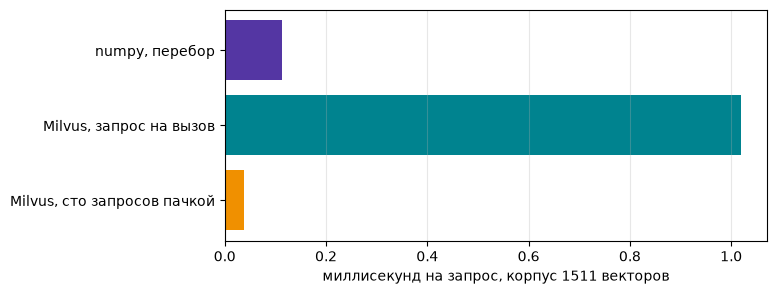

In [37]:
def per_query_ms(fn, n=100):
    started = time.perf_counter()
    fn()
    return (time.perf_counter() - started) * 1000 / n

queries = q_vecs[:100]
speed = {"numpy, перебор": per_query_ms(lambda: [search_numpy(q, line_vecs, 5) for q in queries]),
         "Milvus, запрос на вызов": per_query_ms(lambda: [client.search("lines", data=[q.tolist()], limit=5) for q in queries]),
         "Milvus, сто запросов пачкой": per_query_ms(lambda: client.search("lines", data=queries.tolist(), limit=5))}
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(list(speed), list(speed.values()), color=[COLORS["violet"], COLORS["teal"], COLORS["amber"]])
ax.invert_yaxis(); ax.set_xlabel(f"миллисекунд на запрос, корпус {len(line_vecs)} векторов"); ax.grid(alpha=0.3, axis="x")
{name: round(ms, 2) for name, ms in speed.items()}

,"numpy, перебор","Milvus, запрос на вызов","Milvus, пачкой"
векторов,,,
1511,0.25,1.99,0.13
50000,5.48,1.57,0.14
200000,22.86,1.75,0.16


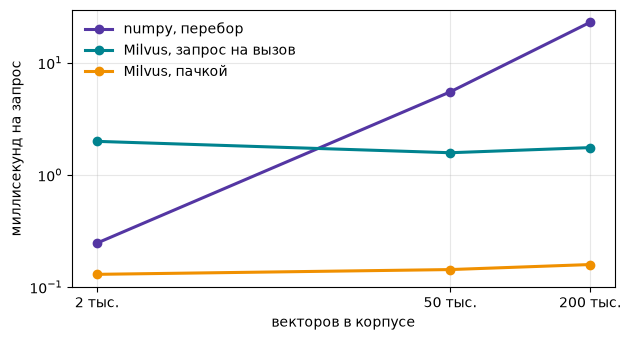

In [38]:
def inflate(vectors, n, noise=0.35, seed=0):
    rng = np.random.default_rng(seed)
    extra = vectors[rng.integers(0, len(vectors), n - len(vectors))]
    extra = extra + noise * rng.standard_normal(extra.shape, dtype=np.float32) / np.sqrt(vectors.shape[1])
    return np.vstack([vectors, extra / np.linalg.norm(extra, axis=1, keepdims=True)])

def wait_index(name, seconds=180):
    for _ in range(seconds):
        info = client.describe_index(name, "vector")
        if info.get("state") == "Finished" and info.get("pending_index_rows", 0) == 0:
            return True
        time.sleep(1)
    return False

scale_rows = []
for n in (len(line_vecs), 50_000, 200_000):
    big = inflate(line_vecs, n)
    if client.has_collection("scale"):
        client.drop_collection("scale")
    client.create_collection("scale", dimension=big.shape[1], metric_type="COSINE")
    for i in range(0, n, 5000):
        client.insert("scale", [{"id": i + j, "vector": v} for j, v in enumerate(big[i:i + 5000].tolist())])
    client.flush("scale")
    wait_index("scale")
    client.search("scale", data=[q_vecs[0].tolist()], limit=5)
    probe = q_vecs[:50]
    scale_rows.append({"векторов": n,
                       "numpy, перебор": per_query_ms(lambda: [search_numpy(q, big, 5) for q in probe], 50),
                       "Milvus, запрос на вызов": per_query_ms(lambda: [client.search("scale", data=[q.tolist()], limit=5) for q in probe], 50),
                       "Milvus, пачкой": per_query_ms(lambda: client.search("scale", data=probe.tolist(), limit=5), 50)})
client.drop_collection("scale")
scale = pd.DataFrame(scale_rows).set_index("векторов")
ax = scale.plot(figsize=(7, 3.6), marker="o", lw=2.2, logx=True, logy=True, color=[COLORS["violet"], COLORS["teal"], COLORS["amber"]])
ax.set_xticks(list(scale.index)); ax.set_xticklabels([f"{n / 1000:.0f} тыс." for n in scale.index]); ax.minorticks_off()
ax.set_ylabel("миллисекунд на запрос"); ax.set_xlabel("векторов в корпусе"); ax.legend(frameon=False); ax.grid(alpha=0.3)
ax.figure.savefig("img/scale.png", dpi=150, bbox_inches="tight")
scale.round(2)

## Спринт 5. RAG-ответ и деньги

Найденные куски кладём в контекст с номерами и просим модель отвечать только по ним, ссылаться на номер источника и честно писать `NOT_FOUND`, если ответа в источниках нет. Правота проверяется как на первом семинаре: нормализованный эталон должен содержаться в ответе.

Дырка: `rag_answer`. После неё два замера на сорока вопросах. Первый: пять конфигураций, с RAG и без, на трёх ярусах моделей, и наша картинка «деньги против качества». Второй: сколько кусков класть в контекст. Recall с ростом k выходит на плато, а счёт за контекст растёт линейно, поэтому k выбирают по кривой, а не на глаз.

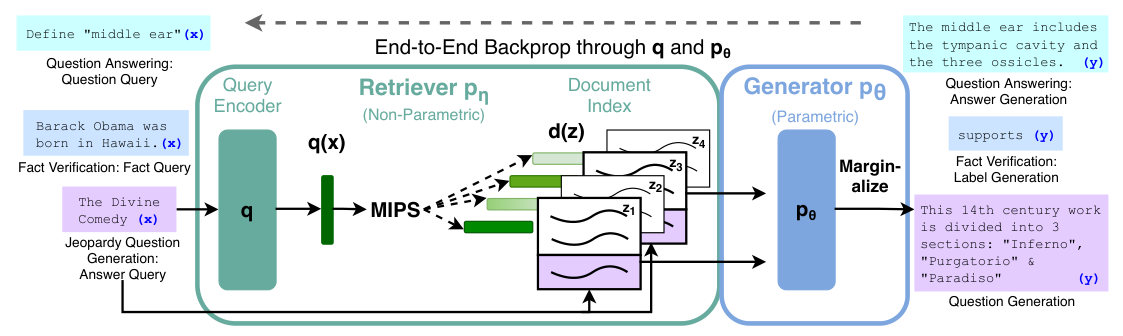

*Lewis et al., 2020. Оригинальная схема RAG: поиск подкладывает куски генератору. У нас то же самое, только через промпт и без обучения*

In [39]:
RAG_SYSTEM = ("Answer the question using only the numbered sources. Cite the source number like [2]. "
              "If the sources do not contain the answer, reply exactly NOT_FOUND. The last line must be FINAL: <short answer>.")
PLAIN_SYSTEM = "Answer the question. If you do not know, reply NOT_FOUND. The last line must be FINAL: <short answer>."

In [40]:
def rag_answer(question, model, k=5, name="lines"):
    hits = search_milvus(name, question, k)
    sources = "\n".join(f"[{i + 1}] ({h['page']}) {h['text']}" for i, h in enumerate(hits))
    before = ledger.mine
    msg = chat([{"role": "system", "content": RAG_SYSTEM},
                {"role": "user", "content": f"Sources\n{sources}\n\nQuestion:{question}"}], model, tag="rag")
    return {"answer": msg.get("content") or "", "hits": hits, "cost": ledger.mine - before}


In [41]:
def plain_answer(question, model):
    before = ledger.mine
    msg = chat([{"role": "system", "content": PLAIN_SYSTEM}, {"role": "user", "content": question}], model, tag="plain")
    return {"answer": msg.get("content") or "", "hits": [], "cost": ledger.mine - before}

def final_answer(text):
    m = re.findall(r"FINAL:\s*(.+)", text or "")
    return m[-1].strip() if m else (text or "").strip()

def is_correct(task, answer):
    return f" {norm(task['answer'])} " in f" {norm(final_answer(answer))} "

def evaluate(fn, sample, config, model, workers=8):
    def one(task):
        try:
            out = fn(task["question"], model)
        except Exception as e:
            out = {"answer": f"ошибка: {e}", "hits": [], "cost": 0.0}
        return {"config": config, "model": model.split("/")[-1], "id": task["id"], "correct": is_correct(task, out["answer"]),
                "found": any(is_gold(h, task) for h in out["hits"]), "refused": "NOT_FOUND" in out["answer"],
                "cost": out["cost"], "answer": final_answer(out["answer"])[:60], "gold": task["answer"]}
    with ThreadPoolExecutor(workers) as pool:
        return pd.DataFrame(list(pool.map(one, sample)))

def report(results):
    g = results.groupby(["config", "model"], sort=False)
    table = g.agg(n=("correct", "size"), accuracy=("correct", "mean"), cost_per_task=("cost", "mean")).reset_index()
    table["cost_per_correct"] = table["cost_per_task"] / table["accuracy"].replace(0, float("nan"))
    return table.round(5)

def money_chart(table, path, baseline=None):
    fig, ax = plt.subplots(figsize=(8, 4.6))
    if baseline:
        ax.axhline(baseline[1] * 100, color=COLORS["grey"], ls="--", lw=1.2)
        ax.annotate(baseline[0], (0.01, baseline[1] * 100 + 1.5), xycoords=("axes fraction", "data"), fontsize=8, color=COLORS["grey"])
    for _, r in table.iterrows():
        color = COLORS["amber"] if "sonnet" in r["model"] else COLORS["teal"] if "haiku" in r["model"] else COLORS["violet"]
        ax.scatter(r["cost_per_task"] * 100, r["accuracy"] * 100, s=110, color=color)
        ax.annotate(f"{r['config']}\n{r['model']}", (r["cost_per_task"] * 100, r["accuracy"] * 100), fontsize=8, xytext=(7, 3), textcoords="offset points")
    ax.set_xscale("log"); ax.set_xlabel("цена вопроса, центы (логарифмическая шкала)"); ax.set_ylabel("доля верных, %"); ax.grid(alpha=0.3)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

out = rag_answer(tasks[0]["question"], MODELS["cheap"])
print(out["answer"], "| эталон:", tasks[0]["answer"], "| цена, центов:", round(out["cost"] * 100, 4))

Релиз «YOUNG and BROKEN» исполнителя 3g0th2002 указан на дату 01/05 в календаре Genius Russia за 2026 год [1]. 

FINAL: 01/05. | эталон: 01/05 | цена, центов: 0.0075


In [46]:
sample = tasks[:20]
results = pd.concat([
    evaluate(plain_answer, sample, "без RAG", MODELS["cheap"]),
    evaluate(plain_answer, sample, "без RAG", MODELS["strong"]),
    evaluate(rag_answer, sample, "RAG, k=3", MODELS["cheap"]),
    evaluate(rag_answer, sample, "RAG, k=3", MODELS["mid"]),
    evaluate(rag_answer, sample, "RAG, k=3", MODELS["strong"]),
], ignore_index=True)
table = report(results)
table

,config,model,n,accuracy,cost_per_task,cost_per_correct
0,без RAG,gpt-4o-mini,20,0.00,0.00001,NaN
1,без RAG,claude-sonnet-4.6,20,0.00,0.00123,NaN
2,"RAG, k=3",gpt-4o-mini,20,0.85,0.00007,0.00008
3,"RAG, k=3",claude-haiku-4.5,20,0.90,0.00074,0.00082
4,"RAG, k=3",claude-sonnet-4.6,20,0.80,0.00181,0.00226


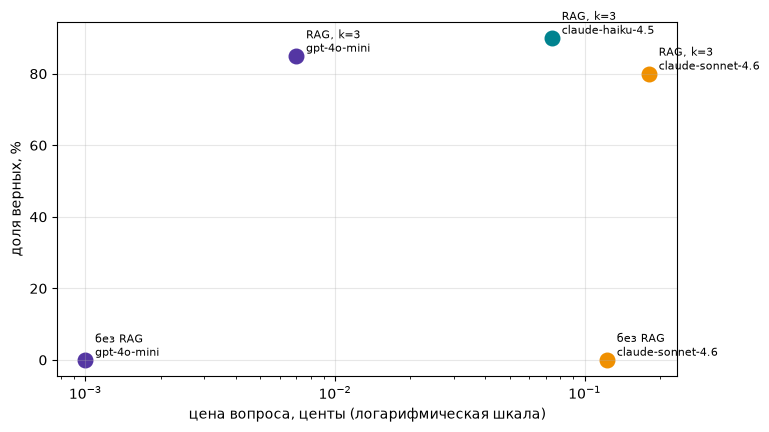

In [47]:
money_chart(table, "img/money_rag.png");

,config,model,n,accuracy,cost_per_task,cost_per_correct
0,k=1,gpt-4o-mini,20,0.65,0.00004,0.00006
1,k=3,gpt-4o-mini,20,0.85,0.00006,0.00006
2,k=5,gpt-4o-mini,20,0.85,0.00007,0.00008
3,k=10,gpt-4o-mini,20,0.85,0.00010,0.00012


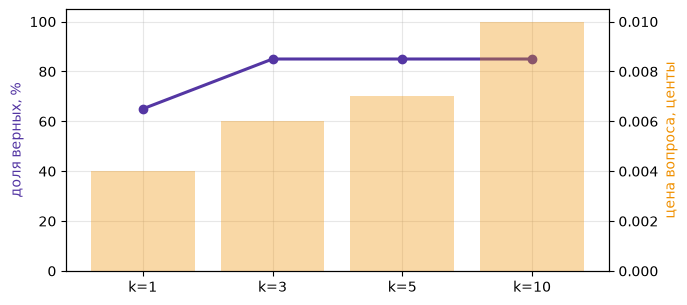

In [48]:
sweep = pd.concat([evaluate(lambda q, m, k=k: rag_answer(q, m, k), sample, f"k={k}", MODELS["cheap"]) for k in (1, 3, 5, 10)], ignore_index=True)
sweep_table = report(sweep)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(sweep_table["config"], sweep_table["accuracy"] * 100, marker="o", lw=2.2, color=COLORS["violet"]); ax.set_ylabel("доля верных, %", color=COLORS["violet"])
ax2 = ax.twinx(); ax2.bar(sweep_table["config"], sweep_table["cost_per_task"] * 100, alpha=0.35, color=COLORS["amber"]); ax2.set_ylabel("цена вопроса, центы", color=COLORS["amber"])
ax.set_ylim(0, 105); ax.grid(alpha=0.3)
sweep_table

## Спринт 6. Разбор провалов

У RAG две половины, и ломаются они по-разному. Поиск мог не найти нужный кусок. А мог найти, но модель ответила неверно или отказалась. Чинятся эти случаи в разных местах, поэтому первым делом раскладываем ошибки на две кучки.

Дальше три приёма. Гибрид: вектор ловит смысл, поиск по словам ловит точные имена и числа, слияние рангов RRF берёт лучшее от обоих. Проверим его на обеих нарезках: и там, где вектору тяжело, и там, где он уже хорош. Отказ: десять вопросов, ответа на которые в корпусе нет, и подсчёт, сколько раз система честно сказала `NOT_FOUND`. Порог близости: у неотвечаемых вопросов лучший кусок заметно дальше, и это дешёвый сигнал для отказа ещё до вызова модели.

Дырка: `rrf`. Чекпоинт: две кучки ошибок, recall до и после гибрида, гистограмма близостей.

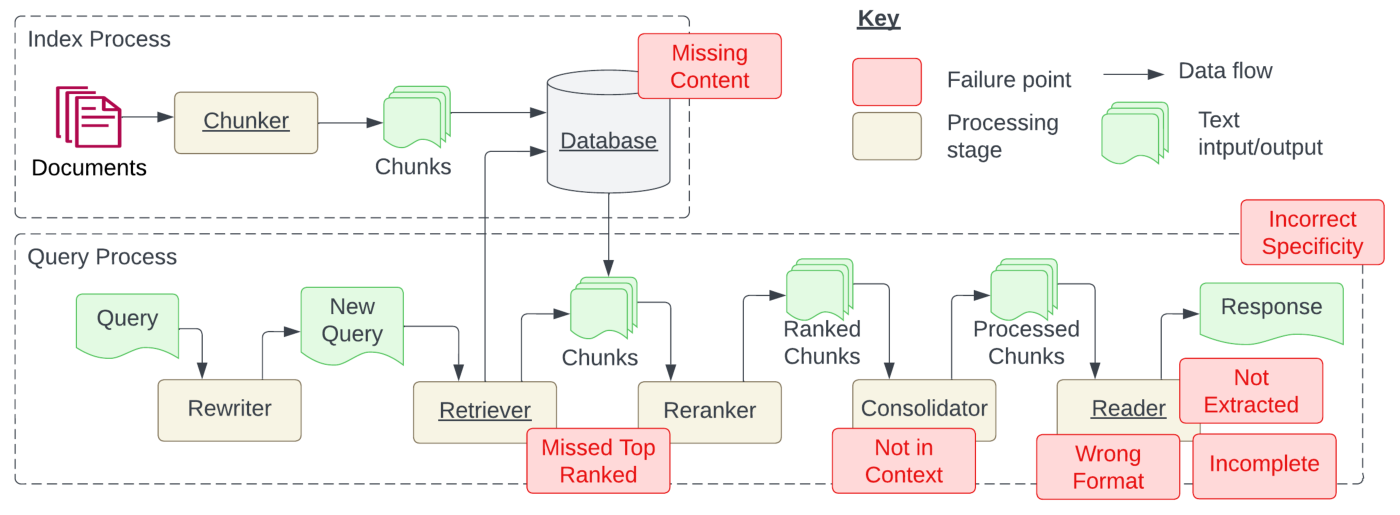

*Barnett et al., 2024. Семь точек отказа RAG из боевых систем: половина до генерации, половина в ней. Мерить надо обе*

In [49]:
def diagnose(results):
    wrong = results[~results["correct"] & results["config"].str.startswith("RAG")]
    return wrong.groupby("model").agg(не_нашли=("found", lambda s: int((~s).sum())), нашли_но_ответ_неверный=("found", "sum"))

diagnose(results)

,не_нашли,нашли_но_ответ_неверный
model,,
claude-haiku-4.5,2,0
claude-sonnet-4.6,2,2
gpt-4o-mini,2,1


In [51]:
results[~results["correct"] & (results["config"] == "RAG, k=3")][["model", "gold", "answer", "found"]]

,model,gold,answer,found
55,gpt-4o-mini,08/05,NOT_FOUND,False
56,gpt-4o-mini,08/05,9 сентября 2026 года.,True
59,gpt-4o-mini,08/05,NOT_FOUND,False
75,claude-haiku-4.5,08/05,NOT_FOUND,False
79,claude-haiku-4.5,08/05,NOT_FOUND,False
89,claude-sonnet-4.6,01/05,1 мая 2026 года,True
94,claude-sonnet-4.6,03/05,3 мая 2026 года,True
95,claude-sonnet-4.6,08/05,NOT_FOUND,False
99,claude-sonnet-4.6,08/05,NOT_FOUND,False


In [52]:
def tokens(text):
    return re.findall(r"\w+", text.lower())

def build_keyword_index(texts):
    docs = [set(tokens(text)) for text in texts]
    df = {}
    for d in docs:
        for w in d:
            df[w] = df.get(w, 0) + 1
    return docs, {w: np.log(len(docs) / n) for w, n in df.items()}

def keyword_search(query, docs, idf, k=20):
    q = set(tokens(query))
    scores = np.array([sum(idf.get(w, 0.0) for w in q & d) for d in docs])
    return [int(i) for i in np.argsort(-scores)[:k]]

In [53]:
def rrf(rankings, k=5, K=60):
    scores = {}
    for ranking in rankings:
        for rank, idx in enumerate(ranking):
            scores[idx] = scores.get(idx, 0.0) + 1 / (K + rank + 1)

    return sorted(scores, key=scores.get, reverse=True)[:k]

,нарезка,поиск,recall@1,recall@5
0,по 400 символов,только вектор,0.21,0.23
1,по 400 символов,только слова,0.21,0.27
2,по 400 символов,гибрид RRF,0.21,0.29
3,по строкам,только вектор,0.97,1.00
4,по строкам,только слова,0.99,1.00
5,по строкам,гибрид RRF,0.98,1.00


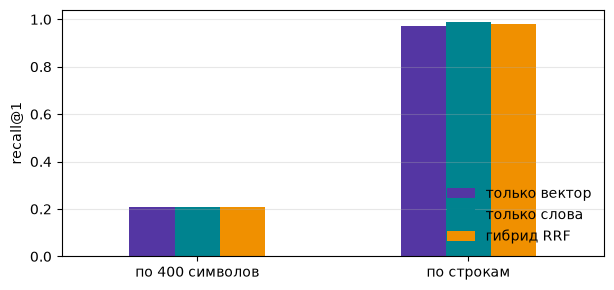

In [54]:
def recall_of(rankings, chunks, k=5):
    return float(np.mean([any(is_gold(chunks[i], t) for i in r[:k]) for r, t in zip(rankings, tasks)]))

rows = []
for cut, chunks, vectors, texts in [("по 400 символов", char_chunks, char_vecs, [c["text"] for c in char_chunks]),
                                    ("по строкам", line_chunks, line_vecs, [emb_text(c) for c in line_chunks])]:
    docs, idf = build_keyword_index(texts)
    by_vector = [[i for i, _ in search_numpy(q, vectors, 20)] for q in q_vecs]
    by_words = [keyword_search(t["question"], docs, idf, 20) for t in tasks]
    by_hybrid = [rrf([v, w], 20) for v, w in zip(by_vector, by_words)]
    rows += [{"нарезка": cut, "поиск": name, "recall@1": recall_of(r, chunks, 1), "recall@5": recall_of(r, chunks, 5)}
             for name, r in [("только вектор", by_vector), ("только слова", by_words), ("гибрид RRF", by_hybrid)]]
hybrid = pd.DataFrame(rows).round(2)
ax = hybrid.pivot(index="нарезка", columns="поиск", values="recall@1")[["только вектор", "только слова", "гибрид RRF"]].plot.bar(
    figsize=(7, 3.2), color=[COLORS["violet"], COLORS["teal"], COLORS["amber"]], rot=0)
ax.set_ylabel("recall@1"); ax.set_xlabel(""); ax.legend(frameon=False, loc="lower right"); ax.grid(alpha=0.3, axis="y")
hybrid

In [55]:
UNANSWERABLE = ["На какую дату в календаре Genius Russia за 2026 год указан релиз «1» исполнителя 1?","На какую дату в календаре Genius Russia за 2026 год указан релиз «1» исполнителя 1?","На какую дату в календаре Genius Russia за 2026 год указан релиз «1» исполнителя 1?","На какую дату в календаре Genius Russia за 2026 год указан релиз «1» исполнителя 1?","На какую дату в календаре Genius Russia за 2026 год указан релиз «1» исполнителя 1?","На какую дату в календаре Genius Russia за 2026 год указан релиз «1» исполнителя 1?","На какую дату в календаре Genius Russia за 2026 год указан релиз «1» исполнителя 1?","На какую дату в календаре Genius Russia за 2026 год указан релиз «1» исполнителя 1?","На какую дату в календаре Genius Russia за 2026 год указан релиз «1» исполнителя 1?","На какую дату в календаре Genius Russia за 2026 год указан релиз «1» исполнителя 1?"]
refusals = [rag_answer(q, MODELS["cheap"]) for q in UNANSWERABLE]
sum("NOT_FOUND" in r["answer"] for r in refusals), [final_answer(r["answer"])[:40] for r in refusals if "NOT_FOUND" not in r["answer"]]

(10, [])

(0.701, 0.617)

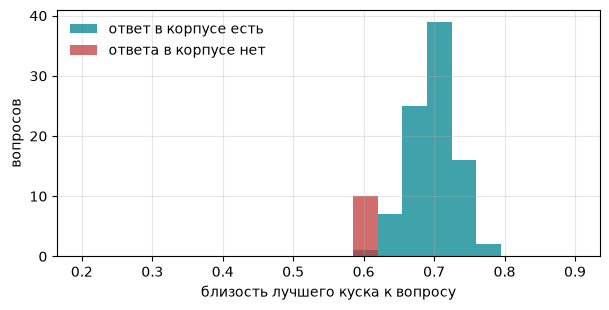

In [56]:
top_answerable = [search_numpy(q, line_vecs, 1)[0][1] for q in q_vecs]
top_unanswerable = [r["hits"][0]["score"] for r in refusals]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(top_answerable, bins=20, range=(0.2, 0.9), alpha=0.75, color=COLORS["teal"], label="ответ в корпусе есть")
ax.hist(top_unanswerable, bins=20, range=(0.2, 0.9), alpha=0.75, color=COLORS["red"], label="ответа в корпусе нет")
ax.set_xlabel("близость лучшего куска к вопросу"); ax.set_ylabel("вопросов"); ax.legend(frameon=False); ax.grid(alpha=0.3)
round(float(np.median(top_answerable)), 3), round(float(np.median(top_unanswerable)), 3)

## Спринт 7. Память агента

У модели памяти нет: помнит ваш код, который кладёт нужное в контекст. Сегодня собираем обе памяти из четвёртой лекции. Эпизодическая: журнал всех реплик в файле, в контекст он не идёт. Семантическая: короткие факты о пользователе, которые дешёвая модель извлекает из диалога отдельным вызовом. Она возвращает обновлённый список целиком, поэтому «переехал», «передумал», «больше не интересуюсь» заменяют старый факт, а не ложатся рядом с ним.

Факты лежат там же, где знания: в Milvus, отдельной коллекцией. К вопросу достаём не все факты, а три ближайших. В контекст идут системный промпт, эти факты, найденные куски корпуса и окно последних реплик. Вся остальная история остаётся в журнале.

Память помогает и поиску. «Что нового в моих темах?» без фактов не ищется никак, а факты, приклеенные к каждому запросу, портят конкретные вопросы: к вопросу про футбол подмешивается хоккей. Поэтому ищем дважды, по самому вопросу и по вопросу с фактами, и сливаем два списка уже знакомым `rrf`. Искать имеет смысл только на вопросы: на «привет, я Лена» база вернёт пять случайных строк, и модель послушно начнёт их пересказывать. Пока это грубая проверка на вопросительный знак, в восьмом спринте решать будет сама модель.

Две дырки: извлечение фактов и поиск по ним. Чекпоинт: во второй сессии агент знает, кто вы и что вам интересно, устаревший факт заменён, а на графике видно, сколько токенов экономит окно с фактами против «тащим всю историю».

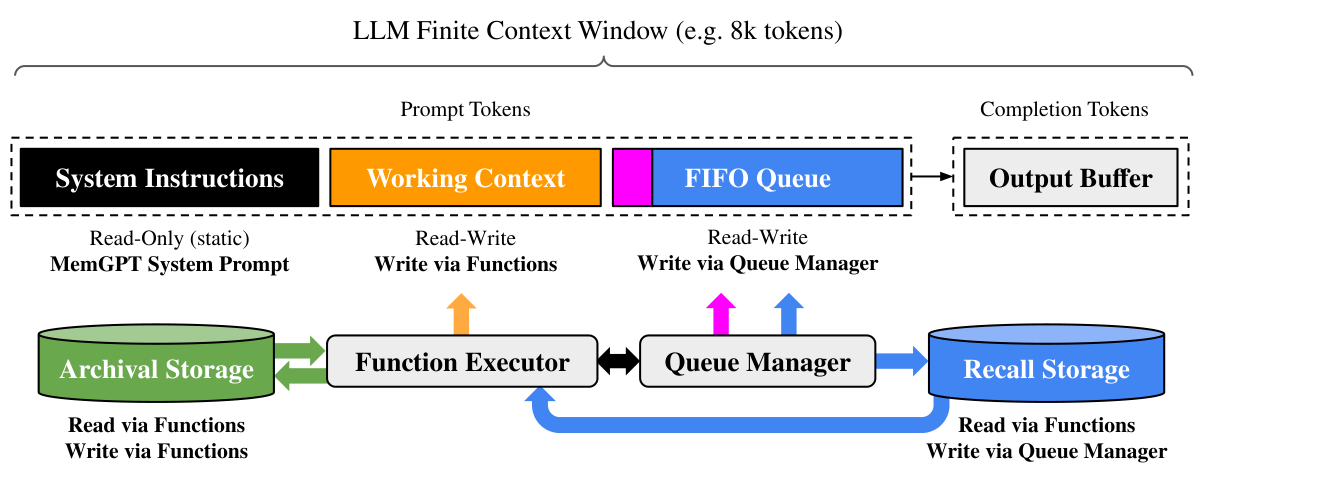

*Packer et al., 2023. MemGPT: контекст как оперативная память, внешние хранилища как диск. В окне живут инструкции, рабочие факты и очередь последних реплик*

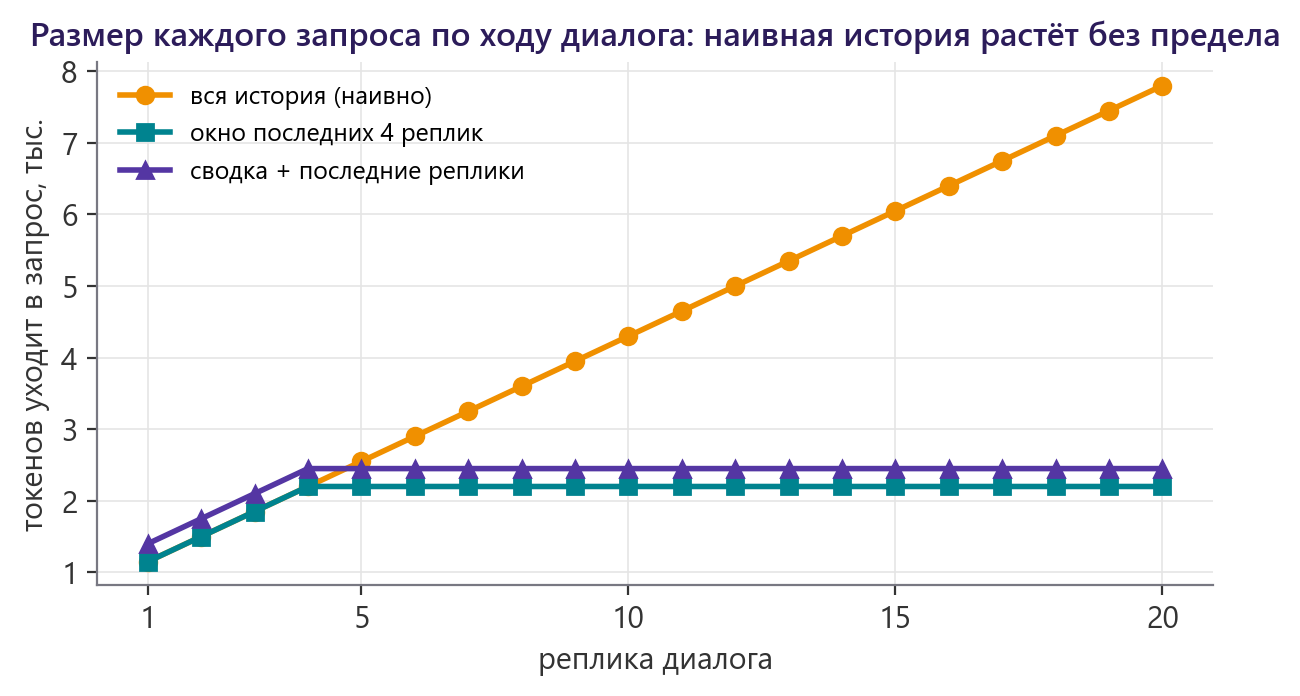

*Из четвёртой лекции: наивная память растёт с каждой репликой, окно и сводка держат запрос плоским*

In [63]:
FACTS_SYSTEM = ("Ты ведёшь память ассистента о пользователе. Верни один JSON-объект вида {\"facts\": [\"...\"]}: полный обновлённый список "
                "коротких фактов о пользователе. Добавь новые устойчивые факты: имя, город, работа, интересы, пожелания к ответам. "
                "Если новый факт отменяет старый, замени старый. Разовые вопросы и мелочи не записывай.")
ASSISTANT_SYSTEM = ("Ты помощник, который отвечает на вопросы по базе знаний. Отвечай на языке пользователя, "
                    "опирайся на источники и на то, что знаешь о пользователе. Источники подобраны автоматически и могут быть не по теме: "
                    "используй только те, что относятся к вопросу. Если в источниках ответа нет, так и скажи.")
JOURNAL, FACTS_FILE = Path("episodes.jsonl"), Path("facts.json")

class Facts(BaseModel):
    facts: list[str] = Field(description="короткие факты о пользователе")

def json_from(text):
    m = re.search(r"\{.*\}", text or "", re.S)
    cleaned = re.sub(r'(\\["\\/bfnrtu])|\\', lambda e: e.group(1) or "\\\\", m.group(0) if m else "{}")
    return json.loads(cleaned, strict=False)

def known_facts():
    return json.loads(FACTS_FILE.read_text(encoding="utf-8")) if FACTS_FILE.exists() else []

def store_facts(facts):
    FACTS_FILE.write_text(json.dumps(facts, ensure_ascii=False, indent=1), encoding="utf-8")
    if facts:
        index_to_milvus("facts", [{"page": "memory", "section": "", "url": "", "text": f} for f in facts], embed_cached(facts))

def remember_episode(session, role, text):
    with JOURNAL.open("a", encoding="utf-8") as f:
        f.write(json.dumps({"session": session, "time": time.strftime("%Y-%m-%d %H:%M:%S"), "role": role, "text": text}, ensure_ascii=False) + "\n")

for path in (JOURNAL, FACTS_FILE):
    path.unlink(missing_ok=True)
if client.has_collection("facts"):
    client.drop_collection("facts")

In [64]:
def extract_facts(dialog, known):
    prompt = f"Известные факты: {json.dumps(known, ensure_ascii=False)}\n\nДиалог:\n{dialog}"
    msg = chat([{"role": "system", "content": FACTS_SYSTEM}, {"role": "user", "content": prompt}], MODELS['cheap'], tag="memory")
    return Facts.model_validate(json_from(msg["content"])).facts

In [65]:
def recall_facts(question, k=3):
    if not client.has_collection("facts"):
        return []
    return [h["text"] for h in search_milvus("facts", question, k)]


In [66]:
def search_with_memory(user_text, facts, k=5):
    plain = search_milvus("lines", user_text, k)
    personal = search_milvus("lines", user_text + " " + " ".join(facts), k) if facts else []
    by_id = {h["id"]: h for h in plain + personal}
    return [by_id[i] for i in rrf([[h["id"] for h in plain], [h["id"] for h in personal]], k)]

def talk(session, history, user_text, mode="память"):
    remember_episode(session, "user", user_text)
    facts = recall_facts(user_text) if mode == "память" else []
    hits = search_with_memory(user_text, facts) if "?" in user_text else []
    sources = "\n".join(f"[{i + 1}] ({h['page']}) {h['text']}" for i, h in enumerate(hits)) or "нет"
    system = ASSISTANT_SYSTEM + ("\nЧто известно о пользователе: " + "; ".join(facts) if facts else "")
    window = history[-4:] if mode == "память" else history
    msg = chat([{"role": "system", "content": system}] + window + [{"role": "user", "content": f"Источники:\n{sources}\n\n{user_text}"}],
               MODELS["cheap"], tag=f"dialog: {mode}")
    answer = msg.get("content") or ""
    history += [{"role": "user", "content": user_text if mode == "память" else f"Источники:\n{sources}\n\n{user_text}"}, {"role": "assistant", "content": answer}]
    remember_episode(session, "assistant", answer)
    return answer

def end_session(history):
    dialog = "\n".join(f"{m['role']}: {m['content'][:400]}" for m in history)
    store_facts(extract_facts(dialog, known_facts()))
    return known_facts()

In [76]:
first = []
print(talk("s1", first, "Привет! Я Илья, разработчик из Минска. Слушаю исполнителя MAYOT, отвечай коротко."))
print(talk("s1", first, "ОРЕО?"))
end_session(first)

Привет, Илья! Рад тебя видеть. Если у тебя есть вопросы о MAYOT или музыке в целом, спрашивай!
Да, 12 июня 2026 года у MAYOT запланирован релиз альбома под названием "ОРЕО". Если тебе интересно, могу рассказать больше о его предыдущих работах или стиле музыки!


['Имя: Илья',
 'Город: Минск',
 'Работа: разработчик',
 'Интересы: музыка, MAYOT',
 'Пожелания к ответам: отвечай коротко']

In [77]:
second = []
print(talk("s2", second, "Какие релизы вышли в мае 2025?"))
print(talk("s2", second, "Музыка не интересна, теперь слежу за футболом. Переехал в Витебск."))
end_session(second)

В мае 2025 года вышли следующие релизы:

- 02/05: SHTRIHCOD — SH3HCO
- 24/05: CODE80 — I Am Not a Human Being
- 30/05: Милок — Не очень бандитская музыка
- 30/05: INSPACE — 44
- 30/05: Sytry Cart — MATRIX
Понял, Илья! Если у тебя есть вопросы о футболе или что-то другое, дай знать. Я постараюсь помочь!


['Имя: Илья',
 'Город: Витебск',
 'Работа: разработчик',
 'Интересы: футбол',
 'Пожелания к ответам: отвечай коротко']

,prompt,cost
tag,,
dialog: память,4720,0.00087
dialog: вся история,15916,0.00172


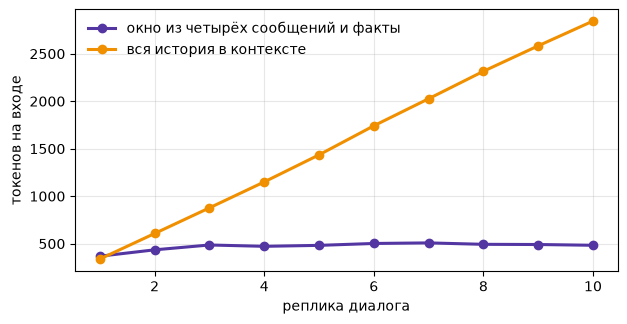

In [78]:
SCRIPT = [t["question"] for t in tasks[40:50]]
for mode in ("память", "вся история"):
    history = []
    for q in SCRIPT:
        talk("bench", history, q, mode)
per_turn = pd.DataFrame([c for c in ledger.calls if c["tag"].startswith("dialog: ")][-2 * len(SCRIPT):])
fig, ax = plt.subplots(figsize=(7, 3.4))
for (tag, part), color in zip(per_turn.groupby("tag", sort=False), [COLORS["violet"], COLORS["amber"]]):
    ax.plot(range(1, len(part) + 1), part["prompt"].values, marker="o", lw=2.2, color=color,
            label={"dialog: память": "окно из четырёх сообщений и факты", "dialog: вся история": "вся история в контексте"}[tag])
ax.set_xlabel("реплика диалога"); ax.set_ylabel("токенов на входе"); ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.savefig("img/memory_tokens.png", dpi=150, bbox_inches="tight")
per_turn.groupby("tag", sort=False).agg(prompt=("prompt", "sum"), cost=("cost", "sum")).round(5)

## Спринт 8. Поиск как инструмент агента

До сих пор поиск делался всегда: пришёл вопрос, нашли куски, ответили. В агенте поиск это инструмент, который модель зовёт сама, когда решит, что ей не хватает знаний. Она может искать несколько раз, уточняя запрос, сузить поиск до одной страницы или не искать вовсе.

Цикл агента берём с первого семинара в сжатом виде. Дырка одна: сам инструмент `knowledge_base` с фильтром по странице. Чекпоинт: те же сорок вопросов двумя способами, «RAG всегда» против «агент решает сам», и итоговая картинка недели. Пунктир на ней это прошлая неделя: поле `agent_ok` в вопросах хранит, ответил ли на вопрос агент с живым поиском по Википедии из первой домашки.

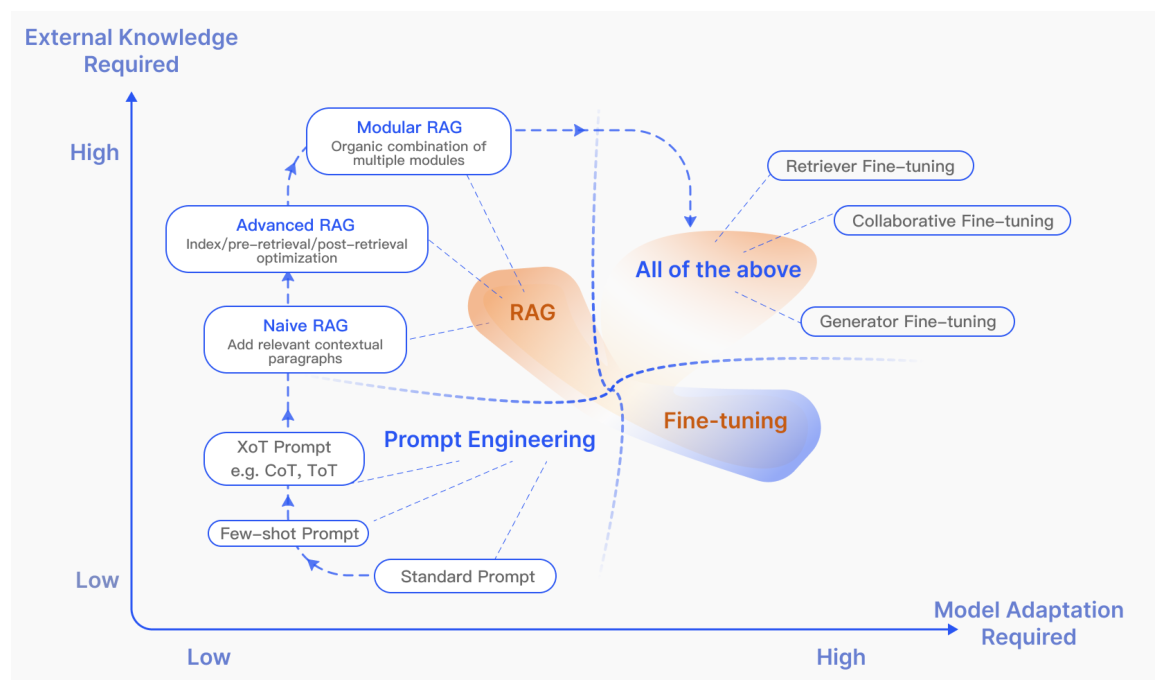

*Gao et al., 2023. Карта приёмов: по вертикали внешние знания, по горизонтали переделка модели. Поиск как инструмент агента это Modular RAG: самый верх карты, а модель мы при этом не трогаем*

In [79]:
TOOLS = {}

def register(fn, args_model, description):
    TOOLS[fn.__name__] = {"fn": fn, "args": args_model, "schema": {"type": "function", "function": {
        "name": fn.__name__, "description": description, "parameters": args_model.model_json_schema()}}}

def run_tool(call):
    name = call["function"]["name"]
    try:
        spec = TOOLS[name]
        result = spec["fn"](**spec["args"].model_validate_json(call["function"]["arguments"]).model_dump())
    except Exception as e:
        result = f"ошибка инструмента {name}: {e}"
    return {"role": "tool", "tool_call_id": call["id"], "content": str(result)[:3000]}

AGENT_SYSTEM = ("You answer questions about events of 2026. Never answer from memory: look facts up with the tools, do not repeat the same call. "
                "When done, write the last line as FINAL: <short answer>, or NOT_FOUND if the knowledge base has no answer.")

def agent(question, model, max_steps=6):
    messages, seen, before = [{"role": "system", "content": AGENT_SYSTEM}, {"role": "user", "content": question}], set(), ledger.mine
    schemas = [t["schema"] for t in TOOLS.values()]
    for step in range(max_steps):
        msg = chat(messages, model, tools=schemas, tag="agent")
        messages.append(msg)
        calls = msg.get("tool_calls") or []
        keys = {(c["function"]["name"], c["function"]["arguments"]) for c in calls}
        if not calls or keys & seen or step == max_steps - 1:
            break
        seen |= keys
        messages += [run_tool(c) for c in calls]
    if calls:
        messages += [{"role": "tool", "tool_call_id": c["id"], "content": "call rejected: answer from what you already have"} for c in calls]
        msg = chat(messages, model, tag="agent")
    searches = sum(m.get("role") == "tool" for m in messages if isinstance(m, dict))
    return {"answer": msg.get("content") or "", "hits": [], "cost": ledger.mine - before, "searches": searches}

class KBArgs(BaseModel):
    query: str = Field(description="short search query in English: names, dates, key terms of the event")
    page: str = Field(default="", description="optional exact page title to search within, for example '2026 in Japan'; empty means all pages")

In [80]:
def knowledge_base(query: str, page: str = "") -> str:
    hits = search_milvus("lines", query, 5, f'page == "{page}"' if page else "")
    if not hits:
        return "nothing found"
    return "\n".join(f"[{h['page']} / {h['section']}] {h['text']}" for h in hits)


In [82]:
register(knowledge_base, KBArgs, "Searches the local knowledge base of 2026 events and returns the five closest facts with their page and section")
out = agent(tasks[3]["question"], MODELS["cheap"])
print(out["answer"], "| эталон:", tasks[3]["answer"], "| обращений к базе:", out["searches"], "| цена, центов:", round(out["cost"] * 100, 4))

Релиз «теперь обо мне знают» исполнителя dabbackwood указан на 1 мая 2026 года. 

FINAL: 01/05/2026 | эталон: 01/05 | обращений к базе: 1 | цена, центов: 0.0131


,config,model,n,accuracy,cost_per_task,cost_per_correct
0,агент с инструментом,gpt-4o-mini,20,0.75,0.00023,0.00031


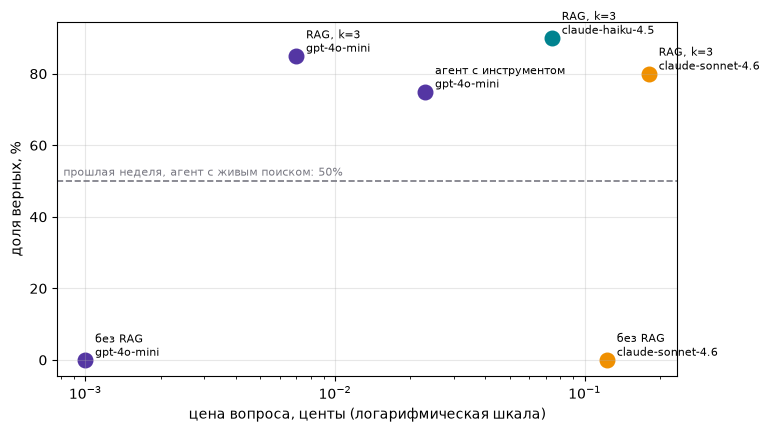

In [88]:
agent_results = evaluate(agent, sample, "агент с инструментом", MODELS["cheap"])
always = results[(results["config"] == "RAG, k=5") & (results["model"] == "gpt-4o-mini")]
final_table = report(pd.concat([results, agent_results], ignore_index=True))
last_week = 0.5
money_chart(final_table, "img/money_all.png", baseline=(f"прошлая неделя, агент с живым поиском: {last_week:.0%}", last_week))
report(pd.concat([always, agent_results], ignore_index=True))

In [87]:
ledger.table(), round(ledger.total, 3)

(                                            calls  prompt  completion     cost
 tag                 model                                                     
 agent               gpt-4o-mini               113   37181        3133  0.00746
 dialog: вся история gpt-4o-mini                10   15916         267  0.00172
 dialog: память      gpt-4o-mini                36   10932        1102  0.00230
 embed               text-embedding-3-small    120  101975           0  0.00204
 memory              gpt-4o-mini                13    3332         670  0.00090
 plain               claude-sonnet-4.6          63    4807        4161  0.07684
                     gpt-4o-mini                63    4086         494  0.00091
 rag                 claude-haiku-4.5           63   21105        5060  0.04640
                     claude-sonnet-4.6          63   21168        3383  0.11425
                     gpt-4o-mini               154   44611        5500  0.00999,
 0.263)

## Дополнение. Тот же конвейер на PDF

Для тех, кто закончил раньше, и для домашки на своём корпусе. PDF это картинка с буквами: текст из него достаётся постранично, колонки и таблицы превращаются в поток строк. Ниже самый простой путь через `pypdf`: страница это кусок, имя файла и номер страницы едут метаданными. Корпусом служат материалы самого курса: пятая и шестая лекции и задание первой недели.

Посмотрите, во что превратилась таблица с критериями оценки: заголовок и строки идут подряд без границ, и нарезка по символам легко оторвёт одно от другого. Для серьёзных документов берут разборщики структуры вроде Docling и Unstructured, о них говорили на шестой лекции.

In [81]:
from pypdf import PdfReader

def pdf_chunks(path):
    reader = PdfReader(str(path))
    pages = [(n + 1, " ".join((p.extract_text() or "").split())) for n, p in enumerate(reader.pages)]
    return [{"page": path.name, "section": f"стр. {n}", "url": "", "text": text} for n, text in pages if len(text) >= 80]

pdf = [c for path in sorted((DATA / "pdf").glob("*.pdf")) for c in pdf_chunks(path)]
index_to_milvus("course", pdf, embed_cached([emb_text(c) for c in pdf]))
save_cache()
len(pdf), next(c["text"][c["text"].find("Критерий Баллы"):][:420] for c in pdf if "Критерий Баллы" in c["text"])

(55,
 'Критерий Баллы Репозиторий запускается с чистого клона, ключа в истории нет 2 Датасет по требованиям, проверка свежести приложена, Sonnet не выше 20 процентов 2 Агент с поиском и чтением страницы, инструменты с тестами 2 Таблица со всеми обязательными строками и картинка 2 Два разобранных провала и честный вывод по тезису 2 Бонус: каскад поверх лучшего агента, строка в таблице и точка на картинке +1 Бонус: второй ист')

In [82]:
COURSE_SYSTEM = RAG_SYSTEM.replace("Answer the question", "Answer in Russian")
for q in ["Что такое RRF и зачем он нужен?", "Какая доля верных ответов Sonnet допустима по критерию свежести в домашнем задании?", "Сколько баллов в домашнем задании дают за два разобранных провала?"]:
    hits = search_milvus("course", q, 3)
    sources = "\n".join(f"[{i + 1}] ({h['page']}, {h['section']}) {h['text'][:3000]}" for i, h in enumerate(hits))
    msg = chat([{"role": "system", "content": COURSE_SYSTEM}, {"role": "user", "content": f"Sources:\n{sources}\n\nQuestion: {q}"}], MODELS["cheap"], tag="pdf")
    print(q, "\n ", " ".join((msg.get("content") or "").split())[:300], "\n  источники:", [(h["page"], h["section"]) for h in hits], "\n")

Что такое RRF и зачем он нужен? 
  RRF (Ranked Reciprocal Fusion) — это метод, который объединяет ранги из разных списков результатов поиска, позволяя учитывать как смысловые, так и точные совпадения. Он используется для того, чтобы каждый способ поиска извлекал то, что умеет, а слияние собирало лучшее в одной строке, что позволяет у 
  источники: [('lecture06.pdf', 'стр. 14'), ('lecture06.pdf', 'стр. 19'), ('lecture05.pdf', 'стр. 24')] 

Какая доля верных ответов Sonnet допустима по критерию свежести в домашнем задании? 
  Доля верных ответов Sonnet 4.6 должна быть не выше 20 процентов по критерию свежести в домашнем задании [3]. FINAL: 20 процентов. 
  источники: [('homework01.pdf', 'стр. 1'), ('lecture06.pdf', 'стр. 17'), ('homework01.pdf', 'стр. 2')] 

Сколько баллов в домашнем задании дают за два разобранных провала? 
  В домашнем задании за два разобранных провала дают 2 балла [2]. FINAL: 2 балла. 
  источники: [('homework01.pdf', 'стр. 4'), ('homework01.pdf', 'стр. 3'), ('lectur

## Домашка

Полное задание в `homework02.pdf`, срок воскресенье 27.09, 23:59. Коротко: перенести этот конвейер на свой корпус, собрать для него двадцать-тридцать вопросов с эталонными кусками, замерить recall@k и цену верного ответа, дать агенту долгую память и показать вторую сессию, в которой он помнит пользователя.